## Practica II.Parte 2

## Presentado por:

## Esteban Garcia Otalvaro
## Fabián Andrés Posso

# Número total de registros y sujetos. 

In [58]:
#Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path


In [43]:


# Ruta de la base de datos sin filtrar
ruta_carpeta = Path(r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\ECGDataDenoised")

todos_los_csvs = list(ruta_carpeta.glob("*.csv"))
print(f"Total de archivos .csv encontrados: {len(todos_los_csvs)}")

nombres_pacientes = []
senales_ii = []

for archivo_csv in todos_los_csvs:
    try:
        # header=None porque no tienen nombres de columnas en la primera fila
        df = pd.read_csv(archivo_csv, header=None)
        
        # Extraer la Derivación II (columna de índice 1)
        senal = df.iloc[:, 1].values
        
        nombres_pacientes.append(archivo_csv.stem)
        senales_ii.append(senal)
    except Exception as e:
        print(f"Error en {archivo_csv.name}: {e}")

print(f"Total de señales de Derivación II cargadas: {len(senales_ii)}")

Total de archivos .csv encontrados: 10646
Total de señales de Derivación II cargadas: 10646


In [44]:
archivos = sorted(
    ruta_carpeta.glob("*.csv")
)

senales = []
nombres = []

for archivo in archivos:

    try:

        df = pd.read_csv(
            archivo,
            header=None
        )

        # Derivación II
        señal = df.iloc[:, 1].values

        senales.append(señal)

        nombres.append(
            archivo.stem
        )

    except Exception as e:

        print(
            f"Error en {archivo.name}: {e}"
        )

print(
    "Numero sujetos:",
    len(senales)
)

Numero sujetos: 10646


Cada archivo es un paciente o sujeto, cada columna es una de las 12 derivaciones del ECG y cada fila son los registros para la respectiva derivación.

In [45]:
primer_archivo = archivos[0]

df_prueba = pd.read_csv(
    primer_archivo,
    header=None
)

print(
    "Archivo:",
    primer_archivo.name
)

print(
    "Número de registros para cada sujeto:",
    df_prueba.shape[0]
)

print(
    "Número de derivaciones del ECG:",
    df_prueba.shape[1]
)

Archivo: MUSE_20180111_155115_19000.csv
Número de registros para cada sujeto: 5000
Número de derivaciones del ECG: 12


Es decir, se trata de 10646 pacientes a los cuales se les tomo 5000 registros de cada una de las 12 derivaciones del ECG.

# Tipos de arritmias o clases disponibles. 

In [46]:
# Cargar el archivo RhythmNames.xlsx para conocer los nombres completos de las arritmias
ruta_rhythms = (
    "RhythmNames.xlsx"  
)
df_rhythms = pd.read_excel(r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\RhythmNames.xlsx")
print("Definiciones de arritmias:")
print(df_rhythms)

# Cargar el archivo Diagnostics.xlsx para mapear cada registro con su sigla de arritmias
ruta_diag = r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\Diagnostics.xlsx"
diagnostics = pd.read_excel(ruta_diag)

# Asumiendo que diagnostics tiene las columnas de nombre de archivo y arritmias
# Vamos a inspeccionar las columnas de diagnostics por seguridad
print("\nColumnas de diagnostics:", diagnostics.columns.tolist())

Definiciones de arritmias:
   Acronym Name                                     Full Name
0          SB                               Sinus Bradycardia
1          SR                                    Sinus Rhythm
2         AFIB                            Atrial Fibrillation
3         ST                                Sinus Tachycardia
4          AF                                  Atrial Flutter
5          SI                              Sinus Irregularity
6          SVT                   Supraventricular Tachycardia
7          AT                              Atrial Tachycardia
8         AVNRT  Atrioventricular  Node Reentrant Tachycardia
9          AVRT        Atrioventricular Reentrant Tachycardia
10        SAAWR       Sinus Atrium to Atrial Wandering Rhythm

Columnas de diagnostics: ['FileName', 'Rhythm', 'Beat', 'PatientAge', 'Gender', 'VentricularRate', 'AtrialRate', 'QRSDuration', 'QTInterval', 'QTCorrected', 'RAxis', 'TAxis', 'QRSCount', 'QOnset', 'QOffset', 'TOffset']


In [50]:
# Asignar los nombres de las 12 derivaciones a las columnas de df_prueba
df_prueba.columns = [
    "I",
    "II",
    "III",
    "aVR",
    "aVL",
    "aVF",
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",
]

# Mostrar el resultado para verificar los nuevos encabezados
display(df_prueba.head())

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,-165.33,-358.97,-121.710,270.25,-28.869,-231.16,448.39,636.52,618.45,-7.8987,-315.16,-570.84
1,-150.75,-336.81,-114.980,251.41,-23.883,-217.52,441.74,646.47,642.56,35.3890,-269.51,-532.21
2,-136.69,-315.56,-108.630,233.45,-19.126,-204.36,436.06,656.31,665.95,76.5720,-225.83,-495.39
3,-123.74,-296.23,-103.090,217.23,-14.815,-192.29,432.27,666.14,688.05,113.5100,-186.00,-461.84
4,-112.57,-279.75,-98.611,203.53,-11.213,-181.87,431.08,676.31,708.47,144.3000,-151.68,-432.56


## Número de sujetos o registros pertenecientes a cada grupo.

In [52]:
# Cargar el archivo de diagnósticos usando la ruta completa
ruta_diag = r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\Diagnostics.xlsx"
diagnostics = pd.read_excel(ruta_diag)

# Verificar las columnas disponibles por si el nombre cambia
print("Columnas en Diagnostics.xlsx:", diagnostics.columns.tolist())

# Obtener y mostrar el número de sujetos/registros por cada grupo (Ritmo)
conteo_grupos = diagnostics["Rhythm"].value_counts()
print("\nNúmero de sujetos por cada grupo de arritmia / ritmo:")
print(conteo_grupos)

Columnas en Diagnostics.xlsx: ['FileName', 'Rhythm', 'Beat', 'PatientAge', 'Gender', 'VentricularRate', 'AtrialRate', 'QRSDuration', 'QTInterval', 'QTCorrected', 'RAxis', 'TAxis', 'QRSCount', 'QOnset', 'QOffset', 'TOffset']

Número de sujetos por cada grupo de arritmia / ritmo:
Rhythm
SB       3889
SR       1826
AFIB     1780
ST       1568
SVT       587
AF        445
SA        399
AT        121
AVNRT      16
AVRT        8
SAAWR       7
Name: count, dtype: int64


## Número de canales disponibles y sus correspondientes derivaciones. 

In [53]:
ruta_carpeta = Path(
    r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\ECGDataDenoised"
)

# Tomar el primer archivo de ejemplo
archivo_ejemplo = sorted(list(ruta_carpeta.glob("*.csv")))[0]

# Cargar el archivo sin encabezados
df_ejemplo = pd.read_csv(archivo_ejemplo, header=None)

# Definir los nombres estándar de las 12 derivaciones
nombres_derivaciones = [
    "I",
    "II",
    "III",
    "aVR",
    "aVL",
    "aVF",
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",
]
df_ejemplo.columns = nombres_derivaciones

# Imprimir resultados del análisis estructural
print(f"Número total de canales (columnas): {df_ejemplo.shape[1]}")
print(f"Derivaciones correspondientes: {list(df_ejemplo.columns)}")

Número total de canales (columnas): 12
Derivaciones correspondientes: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


## Visusalización de datos

In [ ]:
Fs = 500

N = len(senales[0])

duracion = N / Fs

tiempo = np.arange(
    N
) / Fs
print(
    "Frecuencia de muestreo:",
    Fs,
    "Hz"
)

print(
    "Número de muestras:",
    N
)

print(
    "Duración:",
    duracion,
    "segundos"
)

Frecuencia de muestreo: 500 Hz
Número de muestras: 5000
Duración: 10.0 segundos


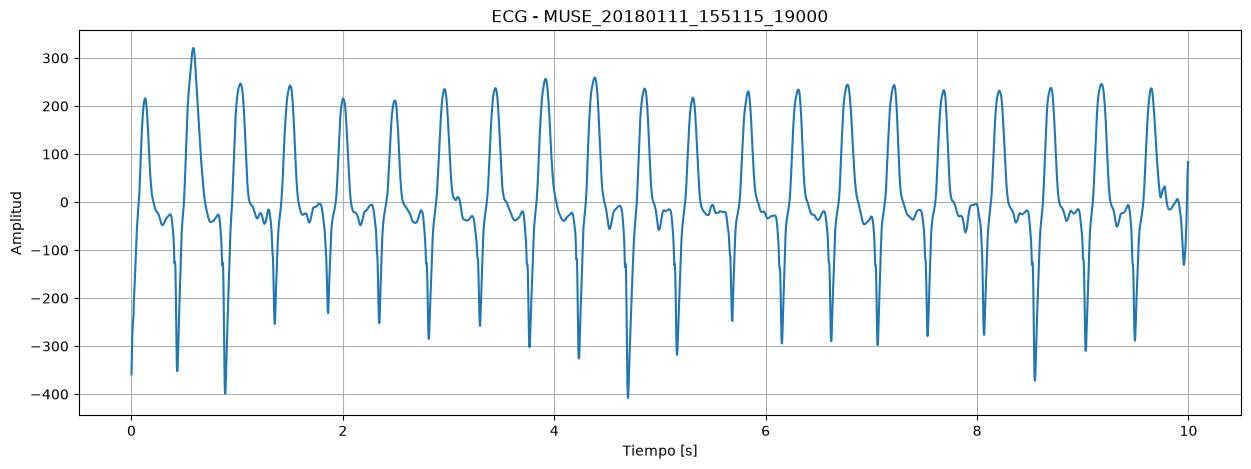

In [55]:
senal_1 = senales[0]

tiempo_1 = np.arange(
    len(senal_1)
) / Fs

plt.figure(figsize=(15,5))

plt.plot(
    tiempo_1,
    senal_1
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.title(
    f"ECG - {nombres[0]}"
)

plt.grid()

plt.show()

,Ritmo / Clase,Número de Registros,Porcentaje (%)
0,SB,3889,36.53
1,SR,1826,17.15
2,AFIB,1780,16.72
3,ST,1568,14.73
4,SVT,587,5.51
5,AF,445,4.18
6,SA,399,3.75
7,AT,121,1.14
8,AVNRT,16,0.15
9,AVRT,8,0.08


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29728\2252627599.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


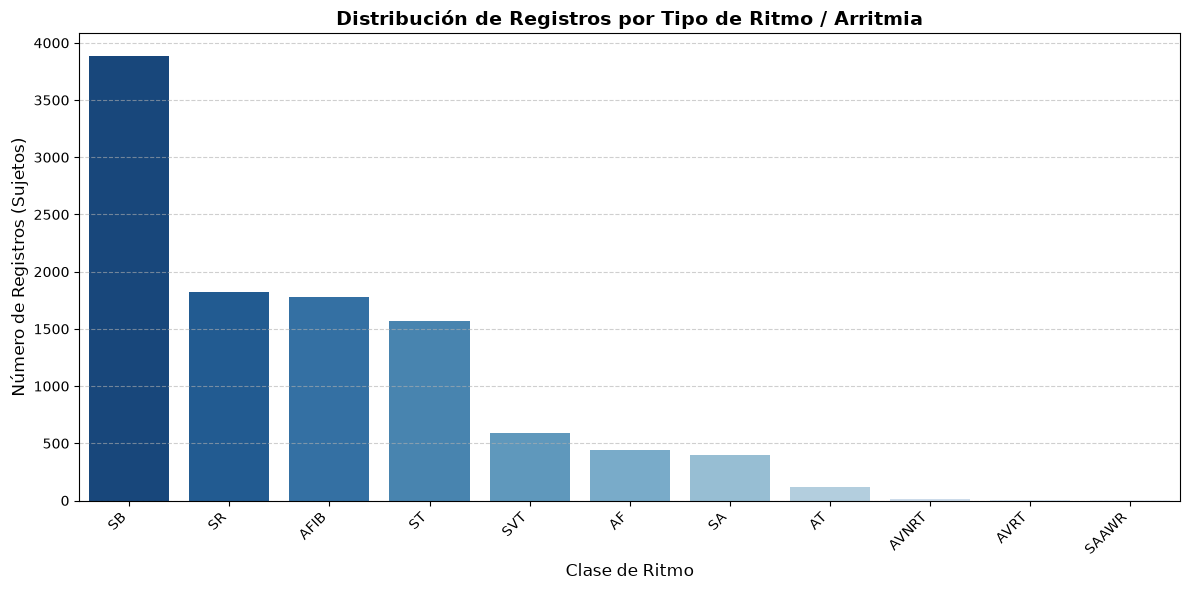

In [57]:
# Calcular la distribución de frecuencias (número de registros por clase/ritmo)
conteo_clases = diagnostics["Rhythm"].value_counts().reset_index()
conteo_clases.columns = ["Ritmo / Clase", "Número de Registros"]

# Calcular el porcentaje de representación de cada clase
total_registros = conteo_clases["Número de Registros"].sum()
conteo_clases["Porcentaje (%)"] = (
    (conteo_clases["Número de Registros"] / total_registros) * 100
).round(2)

# Mostrar la tabla en el entorno 
display(conteo_clases)

# Generar gráfico de barras para visualizar la distribución entre clases
plt.figure(figsize=(12, 6))
sns.barplot(
    data=conteo_clases,
    x="Ritmo / Clase",
    y="Número de Registros",
    palette="Blues_r",
)
plt.title(
    "Distribución de Registros por Tipo de Ritmo / Arritmia",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Clase de Ritmo", fontsize=12)
plt.ylabel("Número de Registros (Sujetos)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
for archivo in archivos[:30]:
    print(archivo.name)

MUSE_20180111_155115_19000.csv
MUSE_20180111_155154_74000.csv
MUSE_20180111_155203_15000.csv
MUSE_20180111_155249_70000.csv
MUSE_20180111_155542_84000.csv
MUSE_20180111_155543_90000.csv
MUSE_20180111_155633_99000.csv
MUSE_20180111_155709_17000.csv
MUSE_20180111_155710_23000.csv
MUSE_20180111_155758_17000.csv
MUSE_20180111_155839_67000.csv
MUSE_20180111_155859_36000.csv
MUSE_20180111_155903_57000.csv
MUSE_20180111_155907_78000.csv
MUSE_20180111_155945_02000.csv
MUSE_20180111_160033_11000.csv
MUSE_20180111_160037_37000.csv
MUSE_20180111_160052_85000.csv
MUSE_20180111_160053_89000.csv
MUSE_20180111_160110_47000.csv
MUSE_20180111_160117_84000.csv
MUSE_20180111_160140_78000.csv
MUSE_20180111_160141_83000.csv
MUSE_20180111_160159_36000.csv
MUSE_20180111_160201_47000.csv
MUSE_20180111_160333_03000.csv
MUSE_20180111_160334_09000.csv
MUSE_20180111_160352_71000.csv
MUSE_20180111_160355_88000.csv
MUSE_20180111_160357_99000.csv


In [ ]:
def calcular_rms(x):

    x = np.asarray(x)

    return np.sqrt(
        np.mean(x**2)
    )
    
from scipy.signal import find_peaks

def detectar_picos(
    señal,
    Fs
):

    distancia = int(
        0.5 * Fs
    )

    prominencia = (
        0.5 * np.std(señal)
    )

    picos, propiedades = find_peaks(
        señal,
        distance=distancia,
        prominence=prominencia
    )

    return picos

def calcular_fc(
    señal,
    Fs
):

    picos = detectar_picos(
        señal,
        Fs
    )

    if len(picos) < 2:

        return np.nan

    intervalos_rr = np.diff(
        picos
    ) / Fs

    frecuencia_cardiaca = (
        60 / np.mean(intervalos_rr)
    )

    return frecuencia_cardiaca

In [ ]:
def extraer_caracteristicas(
    señal,
    Fs
):

    media = np.mean(
        señal
    )

    desviacion = np.std(
        señal,
        ddof=1
    )

    maximo = np.max(
        señal
    )

    minimo = np.min(
        señal
    )

    rms = calcular_rms(
        señal
    )

    fc = calcular_fc(
        señal,
        Fs
    )

    return {

        "Media": media,

        "Desviacion_Estandar":
            desviacion,

        "Maximo": maximo,

        "Minimo": minimo,

        "RMS": rms,

        "Frecuencia_Cardiaca":
            fc
    }

In [ ]:
resultados = []

for señal, nombre in zip(
    senales,
    nombres
):

    caracteristicas = (
        extraer_caracteristicas(
            señal,
            Fs
        )
    )

    caracteristicas[
        "Registro"
    ] = nombre

    resultados.append(
        caracteristicas
    )

In [ ]:
df_caracteristicas = pd.DataFrame(
    resultados
)

df_caracteristicas

,Media,Desviacion_Estandar,Maximo,Minimo,RMS,Frecuencia_Cardiaca,Registro
0,7.522708,124.463597,320.80,-408.120,124.678305,69.848661,MUSE_20180111_155115_19000
1,22.155432,103.610372,565.14,-259.530,105.942556,97.107020,MUSE_20180111_155154_74000
2,23.973741,95.831451,733.81,-64.218,98.775353,65.717415,MUSE_20180111_155203_15000
3,-131.810769,449.811324,420.31,-1747.800,468.683091,110.629067,MUSE_20180111_155249_70000
4,26.529790,129.575647,962.52,-280.820,132.250974,80.131498,MUSE_20180111_155542_84000
...,...,...,...,...,...,...,...
10641,0.000000,0.000000,0.00,0.000,0.000000,NaN,MUSE_20181222_204306_99000
10642,0.000000,0.000000,0.00,0.000,0.000000,NaN,MUSE_20181222_204309_22000
10643,0.000000,0.000000,0.00,0.000,0.000000,NaN,MUSE_20181222_204310_31000
10644,0.000000,0.000000,0.00,0.000,0.000000,NaN,MUSE_20181222_204312_58000


In [ ]:
todos = list(
    ruta_carpeta.iterdir()
)

for archivo in todos:
    print(
        archivo.name
    )

if "clase" in globals():
    etiquetas = pd.Series(clase)

    if len(etiquetas) != len(df_caracteristicas):
        raise ValueError(
            "La cantidad de etiquetas no coincide con la cantidad de registros."
        )

    df_caracteristicas["Clase"] = etiquetas.to_numpy()

else:
    print(
        "No se encontró la variable 'clase'. "
        "Debe cargar las etiquetas de arritmia."
    )

    df_caracteristicas["Clase"] = pd.Series(
        pd.NA,
        index=df_caracteristicas.index,
        dtype="string"
    )
df_caracteristicas.head()
if "Clase" not in df_caracteristicas.columns:
    print(
        "No existe la columna 'Clase'. "
        "Debe cargar un archivo de etiquetas antes de comparar arritmias."
    )

    conteo_clases = pd.Series(dtype="int64")
    grupo_1 = pd.DataFrame(columns=df_caracteristicas.columns)
    grupo_2 = pd.DataFrame(columns=df_caracteristicas.columns)

else:
    conteo_clases = (
        df_caracteristicas["Clase"]
        .value_counts()
    )

    arritmia_1 = "CLASE_1"
    arritmia_2 = "CLASE_2"

    grupo_1 = df_caracteristicas[
        df_caracteristicas["Clase"] == arritmia_1
    ]

    grupo_2 = df_caracteristicas[
        df_caracteristicas["Clase"] == arritmia_2
    ]

print(conteo_clases)

print(
    conteo_clases
)

arritmia_1 = "CLASE_1"
arritmia_2 = "CLASE_2"

grupo_1 = df_caracteristicas[
    df_caracteristicas["Clase"]
    == arritmia_1
]

grupo_2 = df_caracteristicas[
    df_caracteristicas["Clase"]
    == arritmia_2
]

MUSE_20180111_155115_19000.csv
MUSE_20180111_155154_74000.csv
MUSE_20180111_155203_15000.csv
MUSE_20180111_155249_70000.csv
MUSE_20180111_155542_84000.csv
MUSE_20180111_155543_90000.csv
MUSE_20180111_155633_99000.csv
MUSE_20180111_155709_17000.csv
MUSE_20180111_155710_23000.csv
MUSE_20180111_155758_17000.csv
MUSE_20180111_155839_67000.csv
MUSE_20180111_155859_36000.csv
MUSE_20180111_155903_57000.csv
MUSE_20180111_155907_78000.csv
MUSE_20180111_155945_02000.csv
MUSE_20180111_160033_11000.csv
MUSE_20180111_160037_37000.csv
MUSE_20180111_160052_85000.csv
MUSE_20180111_160053_89000.csv
MUSE_20180111_160110_47000.csv
MUSE_20180111_160117_84000.csv
MUSE_20180111_160140_78000.csv
MUSE_20180111_160141_83000.csv
MUSE_20180111_160159_36000.csv
MUSE_20180111_160201_47000.csv
MUSE_20180111_160333_03000.csv
MUSE_20180111_160334_09000.csv
MUSE_20180111_160352_71000.csv
MUSE_20180111_160355_88000.csv
MUSE_20180111_160357_99000.csv
MUSE_20180111_160410_42000.csv
MUSE_20180111_160414_62000.csv
MUSE_201

In [ ]:
arritmia_1 = "CLASE_1"
arritmia_2 = "CLASE_2"

grupo_1 = df_caracteristicas[df_caracteristicas["Clase"] == arritmia_1]
grupo_2 = df_caracteristicas[df_caracteristicas["Clase"] == arritmia_2]

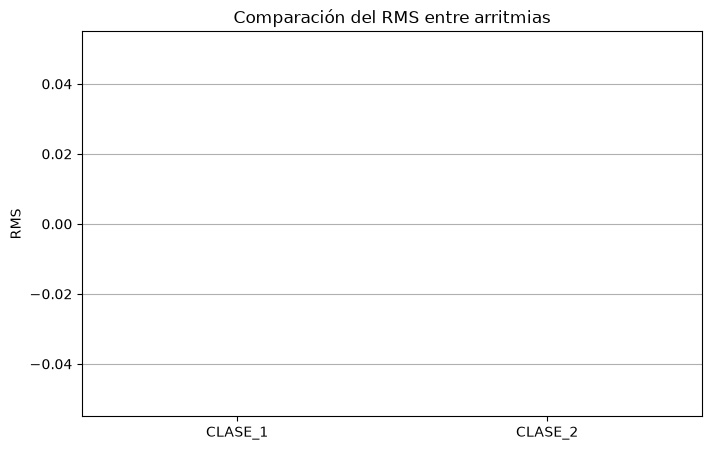

In [ ]:
datos_boxplot = [
    grupo_1["RMS"],
    grupo_2["RMS"]
]

plt.figure(figsize=(8,5))

plt.boxplot(
    datos_boxplot,
    tick_labels=[
        arritmia_1,
        arritmia_2
    ]
)

plt.ylabel(
    "RMS"
)

plt.title(
    "Comparación del RMS entre arritmias"
)

plt.grid(
    axis="y"
)

plt.show()

C:\Users\12345\AppData\Local\Temp\ipykernel_1908\38703238.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


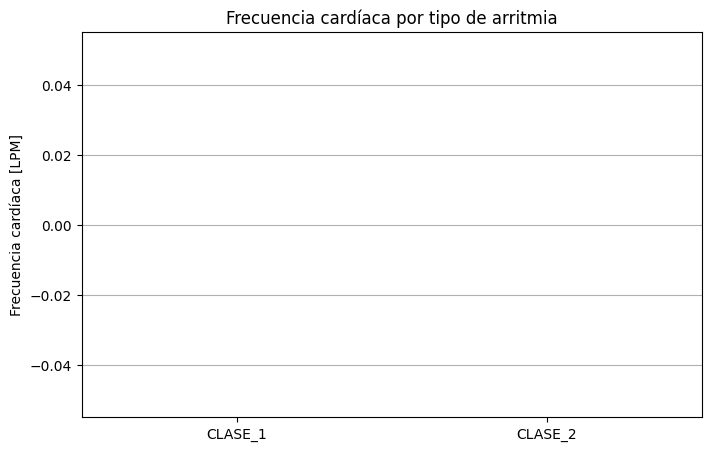

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(

    [
        grupo_1[
            "Frecuencia_Cardiaca"
        ].dropna(),

        grupo_2[
            "Frecuencia_Cardiaca"
        ].dropna()
    ],

    labels=[
        arritmia_1,
        arritmia_2
    ]
)

plt.ylabel(
    "Frecuencia cardíaca [LPM]"
)

plt.title(
    "Frecuencia cardíaca por tipo de arritmia"
)

plt.grid(
    axis="y"
)

plt.show()

C:\Users\12345\AppData\Local\Temp\ipykernel_1908\38703238.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


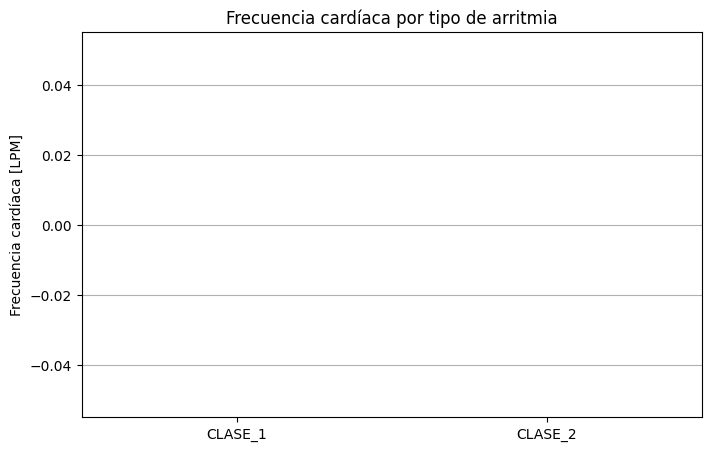

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(

    [
        grupo_1[
            "Frecuencia_Cardiaca"
        ].dropna(),

        grupo_2[
            "Frecuencia_Cardiaca"
        ].dropna()
    ],

    labels=[
        arritmia_1,
        arritmia_2
    ]
)

plt.ylabel(
    "Frecuencia cardíaca [LPM]"
)

plt.title(
    "Frecuencia cardíaca por tipo de arritmia"
)

plt.grid(
    axis="y"
)

plt.show()

C:\Users\12345\AppData\Local\Temp\ipykernel_1908\38703238.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


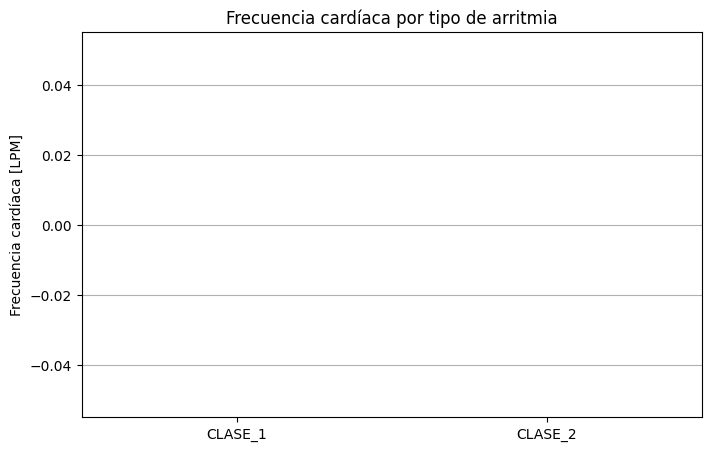

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(

    [
        grupo_1[
            "Frecuencia_Cardiaca"
        ].dropna(),

        grupo_2[
            "Frecuencia_Cardiaca"
        ].dropna()
    ],

    labels=[
        arritmia_1,
        arritmia_2
    ]
)

plt.ylabel(
    "Frecuencia cardíaca [LPM]"
)

plt.title(
    "Frecuencia cardíaca por tipo de arritmia"
)

plt.grid(
    axis="y"
)

plt.show()

C:\Users\12345\AppData\Local\Temp\ipykernel_1908\2159059030.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


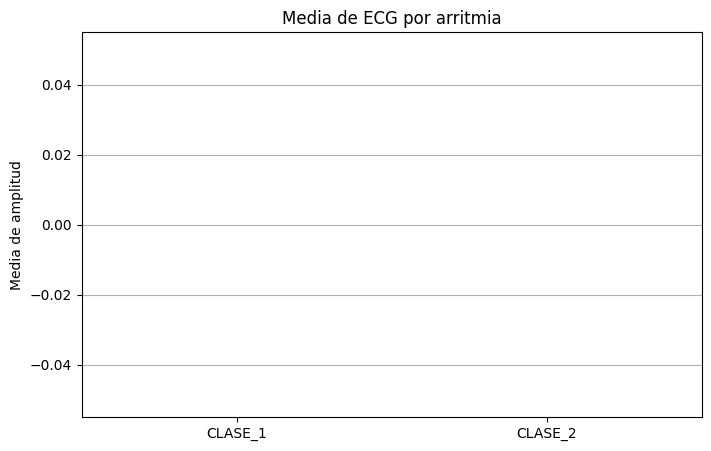

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(

    [
        grupo_1["Media"],
        grupo_2["Media"]
    ],

    labels=[
        arritmia_1,
        arritmia_2
    ]
)

plt.ylabel(
    "Media de amplitud"
)

plt.title(
    "Media de ECG por arritmia"
)

plt.grid(
    axis="y"
)

plt.show()

In [ ]:
from scipy.stats import shapiro

x = grupo_1["RMS"].dropna()
y = grupo_2["RMS"].dropna()

normalidad_1 = shapiro(x)
normalidad_2 = shapiro(y)

print(
    "Grupo 1"
)

print(
    "Estadístico:",
    normalidad_1.statistic
)

print(
    "p-valor:",
    normalidad_1.pvalue
)

print()

print(
    "Grupo 2"
)

print(
    "Estadístico:",
    normalidad_2.statistic
)

print(
    "p-valor:",
    normalidad_2.pvalue
)

Grupo 1
Estadístico: nan
p-valor: nan

Grupo 2
Estadístico: nan
p-valor: nan


C:\Users\12345\AppData\Local\Temp\ipykernel_1908\824782310.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  normalidad_1 = shapiro(x)
C:\Users\12345\AppData\Local\Temp\ipykernel_1908\824782310.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  normalidad_2 = shapiro(y)


In [ ]:
if normalidad_1.pvalue > 0.05:
    print(
        "Grupo 1: compatible con normalidad"
    )
else:
    print(
        "Grupo 1: no cumple normalidad"
    )


if normalidad_2.pvalue > 0.05:
    print(
        "Grupo 2: compatible con normalidad"
    )
else:
    print(
        "Grupo 2: no cumple normalidad"
    )

Grupo 1: no cumple normalidad
Grupo 2: no cumple normalidad


In [ ]:
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

alpha = 0.05

normal_1 = (
    normalidad_1.pvalue > alpha
)

normal_2 = (
    normalidad_2.pvalue > alpha
)

homocedasticidad = (
    resultado_levene.pvalue > alpha
)


if (
    normal_1
    and normal_2
    and homocedasticidad
):

    print(
        "Se cumplen los supuestos."
    )

    print(
        "Se utilizará t de Student."
    )

    resultado = ttest_ind(
        x,
        y,
        equal_var=True
    )

    nombre_prueba = (
        "t de Student"
    )

else:

    print(
        "No se cumplen los supuestos."
    )

    print(
        "Se utilizará Mann-Whitney."
    )

    resultado = mannwhitneyu(
        x,
        y,
        alternative="two-sided"
    )

    nombre_prueba = (
        "U de Mann-Whitney"
    )


print(
    "\nPrueba:",
    nombre_prueba
)

print(
    "Estadístico:",
    resultado.statistic
)

print(
    "p-valor:",
    resultado.pvalue
)

NameError: name 'resultado_levene' is not defined

In [ ]:
%pip install --upgrade pip
# ============================================================
# PARTE 2
# ACERCAMIENTO A LA BASE DE DATOS DE ARRITMIAS CARDÍACAS
# Y COMPARACIÓN ESTADÍSTICA
#
# TODO EL CÓDIGO ES INDEPENDIENTE DE LA PRIMERA PARTE
# ============================================================


# ============================================================
# 1. INSTALACIÓN DE LIBRERÍAS
# ============================================================

!pip install -q numpy pandas matplotlib seaborn scipy openpyxl


# ============================================================
# 2. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from scipy.signal import find_peaks

from scipy.stats import (
    shapiro,
    levene,
    ttest_ind,
    mannwhitneyu
)

#from google.colab import drive

from IPython.display import display


print("Librerías cargadas correctamente.")


# ============================================================
# 3. CONECTAR GOOGLE DRIVE
# ============================================================

drive.mount("/content/drive")

print("Google Drive conectado.")


# ============================================================
# 4. DEFINIR EL DIRECTORIO PRINCIPAL
# ============================================================

DIRECTORIO_PRINCIPAL = Path(
    "/content/drive/MyDrive"
)

print(
    "Directorio principal:",
    DIRECTORIO_PRINCIPAL
)


# ============================================================
# 5. BUSCAR AUTOMÁTICAMENTE ECGDataDenoised
# ============================================================

CARPETAS_ECG = list(
    DIRECTORIO_PRINCIPAL.rglob(
        "ECGDataDenoised"
    )
)

print(
    "Número de carpetas encontradas:",
    len(CARPETAS_ECG)
)

for carpeta_ecg in CARPETAS_ECG:
    print(carpeta_ecg)


# ============================================================
# 6. VERIFICAR QUE EL DATASET EXISTA
# ============================================================

if len(CARPETAS_ECG) == 0:

    raise FileNotFoundError(
        "No se encontró la carpeta ECGDataDenoised "
        "dentro de Google Drive."
    )


# ============================================================
# 7. DEFINIR EL DIRECTORIO DEL DATASET
# ============================================================

DIRECTORIO_DATASET = CARPETAS_ECG[0]

print(
    "\nDataset seleccionado:"
)

print(
    DIRECTORIO_DATASET
)


# ============================================================
# 8. BUSCAR TODOS LOS ARCHIVOS CSV
# ============================================================

ARCHIVOS_CSV = sorted(
    DIRECTORIO_DATASET.rglob("*.csv")
)

print(
    "\nCantidad total de archivos CSV:",
    len(ARCHIVOS_CSV)
)


# ============================================================
# 9. MOSTRAR LOS PRIMEROS ARCHIVOS
# ============================================================

print(
    "\nPrimeros archivos encontrados:"
)

for archivo_csv in ARCHIVOS_CSV[:15]:

    print(
        archivo_csv.name
    )


# ============================================================
# 10. VERIFICAR QUE EXISTAN ARCHIVOS
# ============================================================

if len(ARCHIVOS_CSV) == 0:

    raise FileNotFoundError(
        "La carpeta ECGDataDenoised existe, "
        "pero no contiene archivos CSV."
    )


# ============================================================
# 11. LEER EL PRIMER REGISTRO
# ============================================================

ARCHIVO_PRUEBA = ARCHIVOS_CSV[0]

DATOS_PRUEBA = pd.read_csv(
    ARCHIVO_PRUEBA,
    header=None
)


# ============================================================
# 12. INFORMACIÓN DEL PRIMER REGISTRO
# ============================================================

NUMERO_MUESTRAS = DATOS_PRUEBA.shape[0]

NUMERO_CANALES = DATOS_PRUEBA.shape[1]

print(
    "\nInformación del primer registro"
)

print(
    "Archivo:",
    ARCHIVO_PRUEBA.name
)

print(
    "Número de muestras:",
    NUMERO_MUESTRAS
)

print(
    "Número de canales:",
    NUMERO_CANALES
)

print(
    "\nPrimeras filas:"
)

display(
    DATOS_PRUEBA.head()
)


# ============================================================
# 13. INFORMACIÓN DE TODAS LAS SEÑALES
# ============================================================

LISTA_SEÑALES = []

LISTA_NOMBRES = []

LISTA_NUM_MUESTRAS = []

LISTA_NUM_CANALES = []


for archivo_actual in ARCHIVOS_CSV:

    try:

        datos_actuales = pd.read_csv(
            archivo_actual,
            header=None
        )

        LISTA_SEÑALES.append(
            datos_actuales
        )

        LISTA_NOMBRES.append(
            archivo_actual.stem
        )

        LISTA_NUM_MUESTRAS.append(
            datos_actuales.shape[0]
        )

        LISTA_NUM_CANALES.append(
            datos_actuales.shape[1]
        )

    except Exception as error:

        print(
            "Error leyendo:",
            archivo_actual.name,
            error
        )


# ============================================================
# 14. CREAR DATAFRAME DE INFORMACIÓN
# ============================================================

DF_INFORMACION = pd.DataFrame({

    "Registro":
        LISTA_NOMBRES,

    "Muestras":
        LISTA_NUM_MUESTRAS,

    "Canales":
        LISTA_NUM_CANALES

})


print(
    "\nInformación general de los registros:"
)

display(
    DF_INFORMACION.head()
)


# ============================================================
# 15. EXTRAER DERIVACIÓN II
#
# El notebook original utiliza la columna de índice 1
# como Derivación II.
# ============================================================

LISTA_DERIVACION_II = []

LISTA_NOMBRES_DERIVACION_II = []


for indice_actual in range(
    len(LISTA_SEÑALES)
):

    datos_actuales = (
        LISTA_SEÑALES[indice_actual]
    )

    if datos_actuales.shape[1] > 1:

        señal_actual = (
            datos_actuales.iloc[:, 1]
            .astype(float)
            .values
        )

        LISTA_DERIVACION_II.append(
            señal_actual
        )

        LISTA_NOMBRES_DERIVACION_II.append(
            LISTA_NOMBRES[indice_actual]
        )


print(
    "\nNúmero de señales de Derivación II:",
    len(LISTA_DERIVACION_II)
)


# ============================================================
# 16. DEFINIR FRECUENCIA DE MUESTREO
# ============================================================
#
# IMPORTANTE:
# Esta variable se define exclusivamente para esta parte.
#
# Si la documentación del dataset indica otra frecuencia,
# reemplazar 500 por la frecuencia correspondiente.
# ============================================================

FRECUENCIA_MUESTREO_ECG = 500

print(
    "\nFrecuencia de muestreo:",
    FRECUENCIA_MUESTREO_ECG,
    "Hz"
)


# ============================================================
# 17. CALCULAR DURACIÓN DE CADA REGISTRO
# ============================================================

DF_INFORMACION[
    "Duracion_segundos"
] = (
    DF_INFORMACION["Muestras"]
    / FRECUENCIA_MUESTREO_ECG
)


display(
    DF_INFORMACION.head()
)


# ============================================================
# 18. GRAFICAR LOS PRIMEROS REGISTROS
# ============================================================

NUMERO_GRAFICAS = min(
    3,
    len(LISTA_DERIVACION_II)
)

plt.figure(
    figsize=(14, 9)
)


for indice_grafica in range(
    NUMERO_GRAFICAS
):

    plt.subplot(
        NUMERO_GRAFICAS,
        1,
        indice_grafica + 1
    )

    plt.plot(
        LISTA_DERIVACION_II[indice_grafica]
    )

    plt.title(
        "ECG - " +
        LISTA_NOMBRES_DERIVACION_II[
            indice_grafica
        ]
    )

    plt.xlabel(
        "Muestras"
    )

    plt.ylabel(
        "Amplitud"
    )

    plt.grid(
        True
    )


plt.tight_layout()

plt.show()


# ============================================================
# 19. FUNCIONES ESTADÍSTICAS
# ============================================================

def calcular_media_ecg(señal):

    return np.mean(
        señal
    )


def calcular_desviacion_ecg(señal):

    return np.std(
        señal,
        ddof=1
    )


def calcular_maximo_ecg(señal):

    return np.max(
        señal
    )


def calcular_minimo_ecg(señal):

    return np.min(
        señal
    )


def calcular_rms_ecg(señal):

    return np.sqrt(
        np.mean(
            np.square(señal)
        )
    )


# ============================================================
# 20. FUNCIÓN PARA FRECUENCIA CARDÍACA
# ============================================================

def calcular_frecuencia_cardiaca_ecg(
    señal,
    frecuencia_muestreo
):

    distancia_minima = int(
        0.4 *
        frecuencia_muestreo
    )

    desviacion_señal = np.std(
        señal
    )

    prominencia_minima = (
        0.5 *
        desviacion_señal
    )

    picos, propiedades = find_peaks(

        señal,

        distance=
        distancia_minima,

        prominence=
        prominencia_minima
    )


    if len(picos) < 2:

        return np.nan


    intervalos_rr = (
        np.diff(picos)
        /
        frecuencia_muestreo
    )


    frecuencia_cardiaca = (
        60 /
        np.mean(
            intervalos_rr
        )
    )


    return frecuencia_cardiaca


# ============================================================
# 21. EXTRAER TODAS LAS CARACTERÍSTICAS
# ============================================================

LISTA_RESULTADOS_ECG = []


for indice_señal in range(
    len(LISTA_DERIVACION_II)
):

    señal_actual = (
        LISTA_DERIVACION_II[
            indice_señal
        ]
    )

    nombre_actual = (
        LISTA_NOMBRES_DERIVACION_II[
            indice_señal
        ]
    )


    resultado_actual = {

        "Registro":
            nombre_actual,

        "Media":
            calcular_media_ecg(
                señal_actual
            ),

        "Desviacion_Estandar":
            calcular_desviacion_ecg(
                señal_actual
            ),

        "Maximo":
            calcular_maximo_ecg(
                señal_actual
            ),

        "Minimo":
            calcular_minimo_ecg(
                señal_actual
            ),

        "RMS":
            calcular_rms_ecg(
                señal_actual
            ),

        "Frecuencia_Cardiaca":
            calcular_frecuencia_cardiaca_ecg(
                señal_actual,
                FRECUENCIA_MUESTREO_ECG
            )
    }


    LISTA_RESULTADOS_ECG.append(
        resultado_actual
    )


# ============================================================
# 22. CREAR DATAFRAME FINAL DE CARACTERÍSTICAS
# ============================================================

DF_CARACTERISTICAS_ECG = pd.DataFrame(
    LISTA_RESULTADOS_ECG
)


print(
    "\nCaracterísticas calculadas:"
)

display(
    DF_CARACTERISTICAS_ECG.head()
)


# ============================================================
# 23. ESTADÍSTICA DESCRIPTIVA
# ============================================================

print(
    "\nEstadística descriptiva:"
)

display(
    DF_CARACTERISTICAS_ECG.describe()
)


# ============================================================
# 24. BUSCAR ARCHIVOS DE ETIQUETAS / DIAGNÓSTICOS
# ============================================================

ARCHIVOS_METADATOS = []


for patron_archivo in [
    "*.csv",
    "*.txt",
    "*.xlsx",
    "*.xls",
    "*.mat",
    "*.json"
]:

    archivos_encontrados = list(
        DIRECTORIO_DATASET.rglob(
            patron_archivo
        )
    )

    ARCHIVOS_METADATOS.extend(
        archivos_encontrados
    )


ARCHIVOS_METADATOS = sorted(
    set(ARCHIVOS_METADATOS)
)


print(
    "\nArchivos encontrados dentro del dataset:"
)


for archivo_metadata in ARCHIVOS_METADATOS:

    print(
        archivo_metadata.relative_to(
            DIRECTORIO_DATASET
        )
    )


# ============================================================
# 25. IDENTIFICAR POSIBLES ARCHIVOS DE DIAGNÓSTICO
# ============================================================

PALABRAS_DIAGNOSTICO = [
    "diagnos",
    "label",
    "labels",
    "rhythm",
    "arrhythm",
    "patient",
    "record",
    "annotation",
    "metadata"
]


ARCHIVOS_POSIBLES_ETIQUETAS = []


for archivo_metadata in ARCHIVOS_METADATOS:

    nombre_minuscula = (
        archivo_metadata.name.lower()
    )

    if any(
        palabra in nombre_minuscula
        for palabra in PALABRAS_DIAGNOSTICO
    ):

        ARCHIVOS_POSIBLES_ETIQUETAS.append(
            archivo_metadata
        )


print(
    "\nPosibles archivos de etiquetas:"
)


for archivo_etiqueta in (
    ARCHIVOS_POSIBLES_ETIQUETAS
):

    print(
        archivo_etiqueta
    )


# ============================================================
# 26. BUSCAR AUTOMÁTICAMENTE COLUMNAS DE ETIQUETAS
# ============================================================

COLUMNAS_POSIBLES_DIAGNOSTICO = [

    "diagnosis",
    "diagnostic",
    "diagnostico",
    "diagnóstico",
    "label",
    "labels",
    "rhythm",
    "arrhythmia",
    "arritmia",
    "class",
    "clase",
    "type",
    "tipo"

]


# ============================================================
# 27. LEER ARCHIVOS CSV QUE PUEDAN CONTENER ETIQUETAS
# ============================================================

LISTA_METADATA_CARGADA = []


for archivo_metadata in ARCHIVOS_METADATOS:

    try:

        if (
            archivo_metadata.suffix.lower()
            == ".csv"
        ):

            metadata_actual = pd.read_csv(
                archivo_metadata
            )

            LISTA_METADATA_CARGADA.append(
                (
                    archivo_metadata,
                    metadata_actual
                )
            )

    except Exception:

        pass


# ============================================================
# 28. MOSTRAR COLUMNAS DE LOS CSV
# ============================================================

print(
    "\nColumnas encontradas en archivos CSV:"
)


for archivo_metadata, metadata_actual in (
    LISTA_METADATA_CARGADA
):

    print(
        "\nArchivo:",
        archivo_metadata.name
    )

    print(
        list(
            metadata_actual.columns
        )
    )


# ============================================================
# 29. INTENTAR ENCONTRAR AUTOMÁTICAMENTE
#     EL ARCHIVO DE DIAGNÓSTICOS
# ============================================================

ARCHIVO_DIAGNOSTICO = None

DF_DIAGNOSTICO = None


for archivo_metadata, metadata_actual in (
    LISTA_METADATA_CARGADA
):

    columnas_minusculas = [
        str(columna).lower()
        for columna in
        metadata_actual.columns
    ]


    existe_diagnostico = any(

        any(
            palabra in columna
            for palabra in
            COLUMNAS_POSIBLES_DIAGNOSTICO
        )

        for columna in
        columnas_minusculas
    )


    if existe_diagnostico:

        ARCHIVO_DIAGNOSTICO = (
            archivo_metadata
        )

        DF_DIAGNOSTICO = (
            metadata_actual
        )

        break


# ============================================================
# 30. INFORMAR SI SE ENCONTRARON ETIQUETAS
# ============================================================

if DF_DIAGNOSTICO is None:

    print(
        "\nNo se encontró automáticamente "
        "un archivo de diagnóstico."
    )

    print(
        "Las señales fueron cargadas correctamente, "
        "pero todavía no es posible separar "
        "las arritmias sin conocer sus etiquetas."
    )

else:

    print(
        "\nArchivo de diagnóstico encontrado:"
    )

    print(
        ARCHIVO_DIAGNOSTICO
    )

    print(
        "\nColumnas:"
    )

    print(
        list(
            DF_DIAGNOSTICO.columns
        )
    )

    display(
        DF_DIAGNOSTICO.head()
    )


# ============================================================
# 31. MOSTRAR LAS CARACTERÍSTICAS DISPONIBLES
# ============================================================

print(
    "\n================================================"
)

print(
    "RESUMEN DEL DATASET"
)

print(
    "================================================"
)

print(
    "Registros ECG:",
    len(ARCHIVOS_CSV)
)

print(
    "Canales:",
    NUMERO_CANALES
)

print(
    "Muestras del primer registro:",
    NUMERO_MUESTRAS
)

print(
    "Frecuencia de muestreo:",
    FRECUENCIA_MUESTREO_ECG,
    "Hz"
)

print(
    "Duración primer registro:",
    round(
        NUMERO_MUESTRAS /
        FRECUENCIA_MUESTREO_ECG,
        2
    ),
    "segundos"
)


# ============================================================
# 32. BOXplots DE LAS CARACTERÍSTICAS
# ============================================================

CARACTERISTICAS_GRAFICAS = [

    "Media",

    "Desviacion_Estandar",

    "Maximo",

    "Minimo",

    "RMS",

    "Frecuencia_Cardiaca"

]


for caracteristica in (
    CARACTERISTICAS_GRAFICAS
):

    plt.figure(
        figsize=(8, 5)
    )

    sns.boxplot(
        y=DF_CARACTERISTICAS_ECG[
            caracteristica
        ]
    )

    plt.title(
        "Distribución de " +
        caracteristica
    )

    plt.ylabel(
        caracteristica
    )

    plt.grid(
        True,
        axis="y"
    )

    plt.show()


# ============================================================
# 33. FUNCIÓN PARA COMPARAR DOS GRUPOS
# ============================================================

def comparar_dos_arritmias(
    grupo_1,
    grupo_2,
    nombre_grupo_1,
    nombre_grupo_2,
    alfa=0.05
):


    grupo_1 = np.asarray(
        grupo_1,
        dtype=float
    )

    grupo_2 = np.asarray(
        grupo_2,
        dtype=float
    )


    grupo_1 = grupo_1[
        np.isfinite(grupo_1)
    ]

    grupo_2 = grupo_2[
        np.isfinite(grupo_2)
    ]


    print(
        "\n=============================================="
    )

    print(
        "COMPARACIÓN ESTADÍSTICA"
    )

    print(
        "=============================================="
    )

    print(
        "Grupo 1:",
        nombre_grupo_1
    )

    print(
        "Grupo 2:",
        nombre_grupo_2
    )

    print(
        "n1:",
        len(grupo_1)
    )

    print(
        "n2:",
        len(grupo_2)
    )


    # --------------------------------------------------------
    # NORMALIDAD
    # --------------------------------------------------------

    if (
        len(grupo_1) >= 3
        and
        len(grupo_2) >= 3
    ):

        # Shapiro tiene problemas prácticos con muestras
        # extremadamente grandes.
        # Se utiliza una muestra máxima de 5000 valores.

        muestra_1 = grupo_1[
            :min(
                len(grupo_1),
                5000
            )
        ]

        muestra_2 = grupo_2[
            :min(
                len(grupo_2),
                5000
            )
        ]


        shapiro_1 = shapiro(
            muestra_1
        )

        shapiro_2 = shapiro(
            muestra_2
        )


        print(
            "\nNormalidad:"
        )

        print(
            "Shapiro grupo 1:",
            shapiro_1
        )

        print(
            "Shapiro grupo 2:",
            shapiro_2
        )


        normal_1 = (
            shapiro_1.pvalue
            >
            alfa
        )

        normal_2 = (
            shapiro_2.pvalue
            >
            alfa
        )

    else:

        normal_1 = False

        normal_2 = False


    # --------------------------------------------------------
    # HOMOGENEIDAD DE VARIANZAS
    # --------------------------------------------------------

    prueba_levene = levene(
        grupo_1,
        grupo_2
    )


    print(
        "\nHomogeneidad de varianzas:"
    )

    print(
        "Levene:",
        prueba_levene
    )


    varianzas_homogeneas = (
        prueba_levene.pvalue
        >
        alfa
    )


    # --------------------------------------------------------
    # SELECCIÓN AUTOMÁTICA DE PRUEBA
    # --------------------------------------------------------

    if (
        normal_1
        and
        normal_2
    ):

        if varianzas_homogeneas:

            resultado_prueba = ttest_ind(
                grupo_1,
                grupo_2,
                equal_var=True
            )

            nombre_prueba = (
                "t de Student "
                "para muestras independientes"
            )

        else:

            resultado_prueba = ttest_ind(
                grupo_1,
                grupo_2,
                equal_var=False
            )

            nombre_prueba = (
                "t de Welch"
            )

    else:

        resultado_prueba = mannwhitneyu(
            grupo_1,
            grupo_2,
            alternative="two-sided"
        )

        nombre_prueba = (
            "Mann-Whitney U"
        )


    # --------------------------------------------------------
    # RESULTADO
    # --------------------------------------------------------

    print(
        "\nPrueba seleccionada:"
    )

    print(
        nombre_prueba
    )

    print(
        "\nEstadístico:",
        resultado_prueba.statistic
    )

    print(
        "p-valor:",
        resultado_prueba.pvalue
    )

    print(
        "Alfa:",
        alfa
    )


    # --------------------------------------------------------
    # DECISIÓN
    # --------------------------------------------------------

    if (
        resultado_prueba.pvalue
        <
        alfa
    ):

        decision = (
            "Se rechaza H0."
        )

        interpretacion = (
            "Existe evidencia estadísticamente "
            "significativa de diferencia entre "
            "los dos grupos."
        )

    else:

        decision = (
            "No se rechaza H0."
        )

        interpretacion = (
            "No existe evidencia estadísticamente "
            "significativa de diferencia entre "
            "los dos grupos."
        )


    print(
        "\nDecisión:"
    )

    print(
        decision
    )

    print(
        "\nInterpretación:"
    )

    print(
        interpretacion
    )


    return {

        "Prueba": nombre_prueba,

        "Estadistico":
            resultado_prueba.statistic,

        "p_valor":
            resultado_prueba.pvalue,

        "Alfa":
            alfa,

        "Decision":
            decision,

        "Interpretacion":
            interpretacion

    }


# ============================================================
# 34. FIN DE LA PREPARACIÓN AUTOMÁTICA
# ============================================================

print(
    "\n================================================"
)

print(
    "CARGA Y ANÁLISIS INICIAL COMPLETADOS"
)

print(
    "================================================"
)

print(
    "Todas las variables utilizadas en esta práctica "
    "fueron definidas desde cero."
)

print(
    "No se utiliza ninguna variable de la primera parte."
)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Librerías cargadas correctamente.


NameError: name 'drive' is not defined